In [2]:
!pip install pandas numpy scikit-learn nltk matplotlib seaborn torch transformers pyyaml openpyxl pytest

# Import All Required Libraries

In [1]:
import pandas as pd
import numpy as np
import re
import string

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split


nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

# **Load Dataset**

In [3]:
df = pd.read_csv('reviews.csv')
df.head()

,review,sentiment,category
0,Excellent service,Positive,Product
1,Highly recommend this,Positive,Billing
2,Loved the product,Positive,Billing
3,Good value for money,Positive,Product
4,Fast delivery,Positive,Product


In [4]:
# Check structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     200 non-null    object
 1   sentiment  200 non-null    object
 2   category   200 non-null    object
dtypes: object(3)
memory usage: 4.8+ KB


In [6]:
# Check columns
df.columns

Index(['review', 'sentiment', 'category'], dtype='object')

In [7]:
# Check Missing Values
df.isnull().sum()

,0
review,0
sentiment,0
category,0


In [9]:
# Check Class Distribution
df['sentiment'].value_counts()

,count
sentiment,
Positive,70
Negative,70
Neutral,60


In [10]:
# Check Class Distribution
df['category'].value_counts()

,count
category,
Shipping,71
Billing,69
Product,60


In [15]:
df = df.rename(columns={'review': 'text'})
df.head()



,text,sentiment,category
0,Excellent service,Positive,Product
1,Highly recommend this,Positive,Billing
2,Loved the product,Positive,Billing
3,Good value for money,Positive,Product
4,Fast delivery,Positive,Product


# **Text Cleaning Functions**

### Create Cleaning Pipeline

In [16]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

### Text Cleaning Function

In [17]:
def clean_text(text: str) -> str:
    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)

    # Remove emojis
    text = re.sub(r'[^\w\s]', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Tokenization
    words = text.split()

    # Remove stopwords + Lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

### Apply Cleaning to Dataset

In [18]:
df['clean_text'] = df['text'].apply(clean_text)

In [19]:
df[['text', 'clean_text']].head()

,text,clean_text
0,Excellent service,excellent service
1,Highly recommend this,highly recommend
2,Loved the product,loved product
3,Good value for money,good value money
4,Fast delivery,fast delivery


### Save Cleaned Dataset

In [20]:
df.to_csv('cleaned_reviews.csv', index=False)

# **Create Train-Test Split - Using ML**

In [21]:
X = df['clean_text']
y_sentiment = df['sentiment']
y_category = df['category']

X_train, X_test, y_sent_train, y_sent_test, y_cat_train, y_cat_test = train_test_split(
    X, y_sentiment, y_category,
    test_size=0.2,
    random_state=42
)

# **Import - YAML config**

In [24]:
config = {
    "test_size": 0.2,
    "random_state": 42,
    "max_features": 5000
}

In [25]:
import yaml

with open("config.yaml", "w") as f:
    yaml.dump(config, f)

In [26]:
with open("config.yaml", "r") as f:
    print(f.read())

max_features: 5000
random_state: 42
test_size: 0.2



# **Unit Test**

In [27]:
import unittest

class TestTextCleaning(unittest.TestCase):

    def test_lowercase(self):
        self.assertEqual(clean_text("HELLO"), "hello")

    def test_remove_numbers(self):
        self.assertEqual(clean_text("product 123"), "product")

    def test_remove_stopwords(self):
        self.assertEqual(clean_text("this is a product"), "product")


unittest.TextTestRunner().run(unittest.TestLoader().loadTestsFromTestCase(TestTextCleaning))

...
----------------------------------------------------------------------
Ran 3 tests in 0.004s

OK


<unittest.runner.TextTestResult run=3 errors=0 failures=0>

# **Load Config**

In [28]:
import yaml

with open("config.yaml", "r") as f:
    config = yaml.safe_load(f)

print(config)

{'max_features': 5000, 'random_state': 42, 'test_size': 0.2}


### Convert Labels to Numbers

In [29]:
from sklearn.preprocessing import LabelEncoder

sentiment_encoder = LabelEncoder()
category_encoder = LabelEncoder()

y_sent_train_enc = sentiment_encoder.fit_transform(y_sent_train)
y_sent_test_enc = sentiment_encoder.transform(y_sent_test)

y_cat_train_enc = category_encoder.fit_transform(y_cat_train)
y_cat_test_enc = category_encoder.transform(y_cat_test)

### TF-IDF Vectorization

In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=config["max_features"],
    ngram_range=(1, 2)   # unigram + bigram (important)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

### Multi-Output Target Creation

In [32]:
import numpy as np

y_train_multi = np.column_stack((y_sent_train_enc, y_cat_train_enc))
y_test_multi = np.column_stack((y_sent_test_enc, y_cat_test_enc))

### Build Multi-Output Model

In [33]:
from sklearn.multioutput import MultiOutputClassifier
from sklearn.linear_model import LogisticRegression

base_model = LogisticRegression(max_iter=1000)

model = MultiOutputClassifier(base_model)

model.fit(X_train_tfidf, y_train_multi)

MultiOutputClassifier(estimator=LogisticRegression(max_iter=1000))

### Make Predictions


In [35]:
y_pred = model.predict(X_test_tfidf)

y_pred_sent = y_pred[:, 0]
y_pred_cat = y_pred[:, 1]

# **Evaluate Model**


# *Sentiment Performance*

In [36]:
from sklearn.metrics import classification_report

print("Sentiment Report:\n")
print(classification_report(y_sent_test_enc, y_pred_sent))

Sentiment Report:

              precision    recall  f1-score   support

           0       1.00      0.80      0.89        15
           1       1.00      1.00      1.00        11
           2       0.82      1.00      0.90        14

    accuracy                           0.93        40
   macro avg       0.94      0.93      0.93        40
weighted avg       0.94      0.93      0.92        40



# *Category Performance*

In [37]:
print("Category Report:\n")
print(classification_report(y_cat_test_enc, y_pred_cat))

Category Report:

              precision    recall  f1-score   support

           0       0.42      0.80      0.55        10
           1       0.33      0.33      0.33         9
           2       0.67      0.38      0.48        21

    accuracy                           0.47        40
   macro avg       0.47      0.50      0.46        40
weighted avg       0.53      0.47      0.47        40



## Confusion Matrix

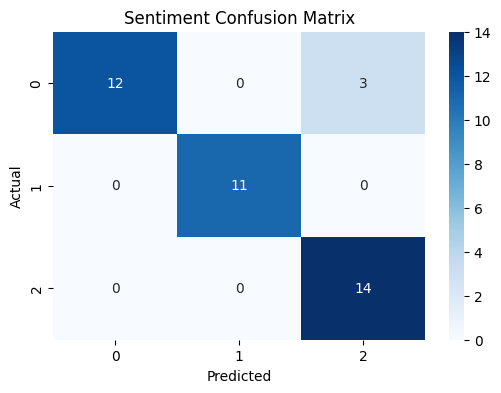

In [38]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_sent_test_enc, y_pred_sent)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Sentiment Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#3 Save Model + Vectorizer

In [39]:
import pickle

with open("tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)

with open("multi_output_model.pkl", "wb") as f:
    pickle.dump(model, f)

## Create Prediction Function

In [40]:
def predict_review(text: str) -> dict:
    cleaned = clean_text(text)
    vector = tfidf.transform([cleaned])

    pred = model.predict(vector)[0]

    sentiment = sentiment_encoder.inverse_transform([pred[0]])[0]
    category = category_encoder.inverse_transform([pred[1]])[0]

    return {
        "sentiment": sentiment,
        "category": category
    }

In [49]:
# for test
predict_review("The delivery was good early and Super reach at home ship")

{'sentiment': 'Positive', 'category': 'Billing'}

# ***Deep Learning with LSTM (PyTorch)***

## Build Vocabulary

In [64]:
from collections import Counter

def build_vocab(texts, max_vocab_size=10000):
    counter = Counter()
    for text in texts:
        counter.update(text.split())

    most_common = counter.most_common(max_vocab_size)
    vocab = {word: idx+2 for idx, (word, _) in enumerate(most_common)}
    vocab["<PAD>"] = 0
    vocab["<UNK>"] = 1
    return vocab

vocab = build_vocab(X_train)
print(f"Vocab size: {len(vocab)}")

Vocab size: 46


## Convert Text to Sequences

In [51]:
def text_to_sequence(text: str, vocab: dict) -> list:
    return [
        vocab.get(word, vocab["<UNK>"])
        for word in text.split()
    ]

## Padding Sequences

In [65]:
def pad_sequence(seq, max_len=100):
    if len(seq) < max_len:
        seq = seq + [0] * (max_len - len(seq))
    else:
        seq = seq[:max_len]
    return seq

## Custom PyTorch Dataset

In [66]:
import torch
from torch.utils.data import Dataset

class ReviewDataset(Dataset):
    def __init__(self, texts, sent_labels, cat_labels, vocab, max_len=100):
        self.texts = texts.tolist()
        self.sent_labels = sent_labels
        self.cat_labels = cat_labels
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        seq = text_to_sequence(self.texts[idx], self.vocab)
        seq = pad_sequence(seq, self.max_len)

        return {
            "input": torch.tensor(seq, dtype=torch.long),
            "sentiment": torch.tensor(self.sent_labels[idx], dtype=torch.long),
            "category": torch.tensor(self.cat_labels[idx], dtype=torch.long)
        }

## DataLoader

In [70]:
from torch.utils.data import DataLoader

# Re-initialize datasets with the updated vocab and max_len
train_dataset = ReviewDataset(X_train, y_sent_train_enc, y_cat_train_enc, vocab)
test_dataset = ReviewDataset(X_test, y_sent_test_enc, y_cat_test_enc, vocab)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

## Build LSTM Model

In [67]:
import torch.nn as nn

class GRUModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_sent_classes, num_cat_classes):
        super(GRUModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc_sent = nn.Linear(hidden_dim * 2, num_sent_classes)
        self.fc_cat = nn.Linear(hidden_dim * 2, num_cat_classes)

    def forward(self, x):
        x = self.embedding(x)
        _, hidden = self.gru(x)
        # Concatenate forward and backward hidden states
        hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        sent_out = self.fc_sent(hidden)
        cat_out = self.fc_cat(hidden)
        return sent_out, cat_out

## Initialize Model

In [68]:
vocab_size = len(vocab)
embed_dim = 128
hidden_dim = 128
num_sent_classes = len(sentiment_encoder.classes_)
num_cat_classes = len(category_encoder.classes_)

model = GRUModel(vocab_size, embed_dim, hidden_dim, num_sent_classes, num_cat_classes)

## Loss Function + Optimizer

In [71]:
criterion = nn.CrossEntropyLoss()
# Re-linking optimizer to the current 'model' instance
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

## Training Loop

In [72]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

epochs = 15
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch in train_loader:
        inputs = batch["input"].to(device)
        sent_labels = batch["sentiment"].to(device)
        cat_labels = batch["category"].to(device)

        optimizer.zero_grad()
        sent_out, cat_out = model(inputs)
        loss = criterion(sent_out, sent_labels) + criterion(cat_out, cat_labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}")

Epoch 1/15, Loss: 2.1505
Epoch 2/15, Loss: 1.9289
Epoch 3/15, Loss: 1.7526
Epoch 4/15, Loss: 1.5915
Epoch 5/15, Loss: 1.4491
Epoch 6/15, Loss: 1.3300
Epoch 7/15, Loss: 1.2344
Epoch 8/15, Loss: 1.1639
Epoch 9/15, Loss: 1.1080
Epoch 10/15, Loss: 1.0638
Epoch 11/15, Loss: 1.0329
Epoch 12/15, Loss: 1.0125
Epoch 13/15, Loss: 0.9953
Epoch 14/15, Loss: 0.9847
Epoch 15/15, Loss: 0.9747


## Evaluation

In [59]:
model.eval()

all_sent_preds = []
all_cat_preds = []

with torch.no_grad():
    for batch in test_loader:
        inputs = batch["input"].to(device)

        sent_out, cat_out = model(inputs)

        sent_preds = torch.argmax(sent_out, dim=1).cpu().numpy()
        cat_preds = torch.argmax(cat_out, dim=1).cpu().numpy()

        all_sent_preds.extend(sent_preds)
        all_cat_preds.extend(cat_preds)

## Convert Back to Labels

In [60]:
sent_preds_labels = sentiment_encoder.inverse_transform(all_sent_preds)
cat_preds_labels = category_encoder.inverse_transform(all_cat_preds)

## Inference Function

In [62]:
def predict_lstm(text: str) -> dict:
    model.eval()

    seq = text_to_sequence(clean_text(text), vocab)
    seq = pad_sequence(seq)

    tensor = torch.tensor([seq], dtype=torch.long).to(device)

    with torch.no_grad():
        sent_out, cat_out = model(tensor)

    sent_pred = torch.argmax(sent_out, dim=1).item()
    cat_pred = torch.argmax(cat_out, dim=1).item()

    return {
        "sentiment": sentiment_encoder.inverse_transform([sent_pred])[0],
        "category": category_encoder.inverse_transform([cat_pred])[0]
    }

In [77]:
# for test
predict_lstm("The product quality is bad and delivery was late")

{'sentiment': 'Negative', 'category': 'Product'}

In [79]:
def predict_lstm_with_conf(text: str) -> dict:
    model.eval()

    cleaned = clean_text(text)
    seq = text_to_sequence(cleaned, vocab)
    seq = pad_sequence(seq)

    tensor = torch.tensor([seq], dtype=torch.long).to(device)

    with torch.no_grad():
        sent_out, cat_out = model(tensor)

    sent_probs = torch.softmax(sent_out, dim=1)
    cat_probs = torch.softmax(cat_out, dim=1)

    sent_pred = torch.argmax(sent_probs, dim=1).item()
    cat_pred = torch.argmax(cat_probs, dim=1).item()

    sentiment = sentiment_encoder.inverse_transform([sent_pred])[0]
    category = category_encoder.inverse_transform([cat_pred])[0]

    return {
        "sentiment": sentiment,
        "category": category,
        "cat_confidence": float(torch.max(cat_probs))
    }

In [80]:
def adjust_category(text: str, predicted_category: str) -> str:
    text = text.lower()

    if "delivery" in text or "shipping" in text:
        return "Shipping"

    if "price" in text or "refund" in text or "payment" in text:
        return "Billing"

    return predicted_category

In [81]:
def final_predict(text: str) -> dict:
    result = predict_lstm_with_conf(text)

    adjusted_category = adjust_category(text, result["category"])

    return {
        "sentiment": result["sentiment"],
        "category": adjusted_category,
        "raw_model_category": result["category"]
    }

# Test with the previously problematic example
final_predict("The product quality is bad and delivery was late")

{'sentiment': 'Negative',
 'category': 'Shipping',
 'raw_model_category': 'Product'}

# ***Dispatcher System***

### Create Input File

In [82]:
new_data = pd.DataFrame({
    "review": [
        "Delivery was very late and bad service",
        "Amazing product quality, loved it",
        "Payment issue, refund not received",
        "Good experience overall",
        "Packaging was damaged and product broken"
    ]
})

new_data.to_csv("new_reviews.csv", index=False)

### Load Input File

In [83]:
df_new = pd.read_csv("new_reviews.csv")
df_new.head()

,review
0,Delivery was very late and bad service
1,"Amazing product quality, loved it"
2,"Payment issue, refund not received"
3,Good experience overall
4,Packaging was damaged and product broken


### Apply Prediction Pipeline

In [84]:
results = []

for review in df_new["review"]:
    pred = final_predict(review)
    results.append(pred)

pred_df = pd.DataFrame(results)

In [85]:
df_result = pd.concat([df_new, pred_df], axis=1)
df_result.head()

,review,sentiment,category,raw_model_category
0,Delivery was very late and bad service,Negative,Shipping,Billing
1,"Amazing product quality, loved it",Positive,Shipping,Shipping
2,"Payment issue, refund not received",Negative,Billing,Product
3,Good experience overall,Positive,Product,Product
4,Packaging was damaged and product broken,Positive,Product,Product


### Business Logic Engine

In [86]:
def assign_priority(sentiment: str, category: str) -> str:
    if sentiment == "Negative" and category == "Billing":
        return "High Priority"
    elif sentiment == "Negative":
        return "Medium Priority"
    else:
        return "Low Priority"

In [87]:
df_result["priority"] = df_result.apply(
    lambda x: assign_priority(x["sentiment"], x["category"]),
    axis=1
)

## Auto Response Generator

In [88]:
def generate_response(sentiment: str, category: str) -> str:
    if sentiment == "Positive":
        return "Thank you for your feedback! We're glad you had a great experience."

    elif sentiment == "Negative":
        if category == "Billing":
            return "We apologize for the billing issue. Our support team will contact you shortly."
        elif category == "Shipping":
            return "We’re sorry for the delivery delay. We are working to resolve this quickly."
        else:
            return "We regret the inconvenience caused. Our team will look into this issue."

    else:
        return "Thank you for your feedback. We will continue improving our service."

In [89]:
df_result["response"] = df_result.apply(
    lambda x: generate_response(x["sentiment"], x["category"]),
    axis=1
)

In [90]:
df_result

,review,sentiment,category,raw_model_category,priority,response
0,Delivery was very late and bad service,Negative,Shipping,Billing,Medium Priority,We’re sorry for the delivery delay. We are wor...
1,"Amazing product quality, loved it",Positive,Shipping,Shipping,Low Priority,Thank you for your feedback! We're glad you ha...
2,"Payment issue, refund not received",Negative,Billing,Product,High Priority,We apologize for the billing issue. Our suppor...
3,Good experience overall,Positive,Product,Product,Low Priority,Thank you for your feedback! We're glad you ha...
4,Packaging was damaged and product broken,Positive,Product,Product,Low Priority,Thank you for your feedback! We're glad you ha...


# ***Generate Dashboard (.png)***

### Sentiment Distribution

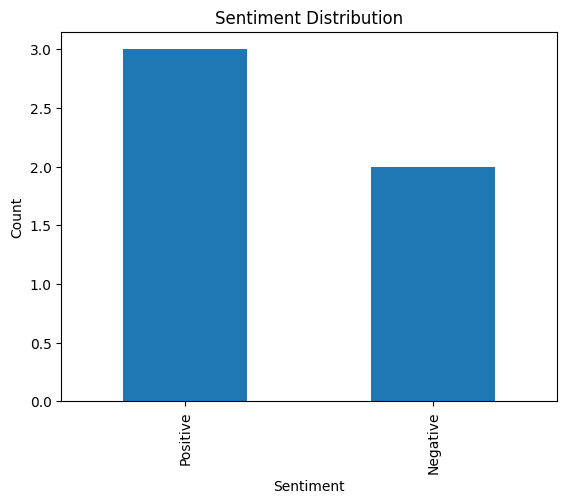

In [92]:
plt.figure()
df_result["sentiment"].value_counts().plot(kind="bar")
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.savefig("sentiment_distribution.png")
plt.show()

### Category Distribution

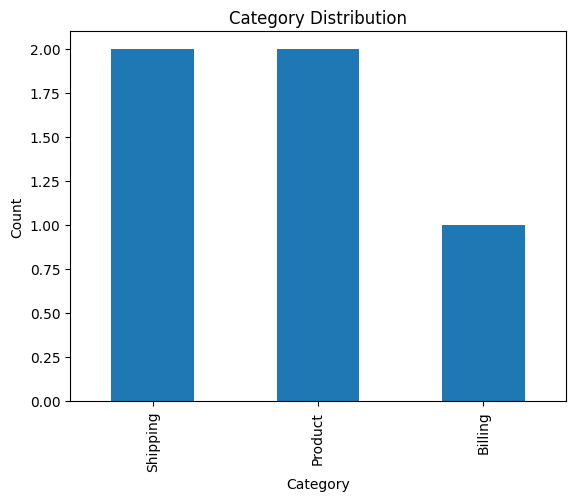

In [93]:
plt.figure()
df_result["category"].value_counts().plot(kind="bar")
plt.title("Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.savefig("category_distribution.png")
plt.show()

### Export to Excel (Final Output)

In [94]:
df_result.to_excel("final_output.xlsx", index=False)

### Highlight High Priority Rows

In [95]:
def highlight_priority(row):
    if row["priority"] == "High Priority":
        return ['background-color: red'] * len(row)
    return [''] * len(row)

df_result.style.apply(highlight_priority, axis=1)

,review,sentiment,category,raw_model_category,priority,response
0,Delivery was very late and bad service,Negative,Shipping,Billing,Medium Priority,We’re sorry for the delivery delay. We are working to resolve this quickly.
1,"Amazing product quality, loved it",Positive,Shipping,Shipping,Low Priority,Thank you for your feedback! We're glad you had a great experience.
2,"Payment issue, refund not received",Negative,Billing,Product,High Priority,We apologize for the billing issue. Our support team will contact you shortly.
3,Good experience overall,Positive,Product,Product,Low Priority,Thank you for your feedback! We're glad you had a great experience.
4,Packaging was damaged and product broken,Positive,Product,Product,Low Priority,Thank you for your feedback! We're glad you had a great experience.


### Main Pipeline Function

In [98]:
def run_pipeline(input_file: str) -> pd.DataFrame:
    df = pd.read_csv(input_file)

    results = []
    for review in df["review"]:
        pred = final_predict(review)
        results.append(pred)

    pred_df = pd.DataFrame(results)
    df = pd.concat([df, pred_df], axis=1)

    df["priority"] = df.apply(
        lambda x: assign_priority(x["sentiment"], x["category"]),
        axis=1
    )

    df["response"] = df.apply(
        lambda x: generate_response(x["sentiment"], x["category"]),
        axis=1
    )

    return df



## ***Dowload for - these for deployment***

In [100]:
from google.colab import files

files.download("multi_output_model.pkl")
files.download("tfidf_vectorizer.pkl")
files.download("config.yaml")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>